In [1]:
import pandas as pd

triazine_df = pd.read_csv("../data/virtual_triazines_filtered.csv")

In [6]:
import os
import sys
from rdkit import RDConfig
from rdkit import Chem
sys.path.append(
    os.path.join(RDConfig.RDContribDir, "SA_Score")
)

import sascorer

triazine_df["mol"] = triazine_df["SMILES"].apply(
    Chem.MolFromSmiles
)

triazine_df["SA_Score"] = (
    triazine_df["mol"]
    .apply(sascorer.calculateScore)
)

triazine_df["SA_Score"].describe()

count    5039.000000
mean        2.771913
std         0.469017
min         1.846853
25%         2.453869
50%         2.683786
75%         2.974381
max         6.475175
Name: SA_Score, dtype: float64

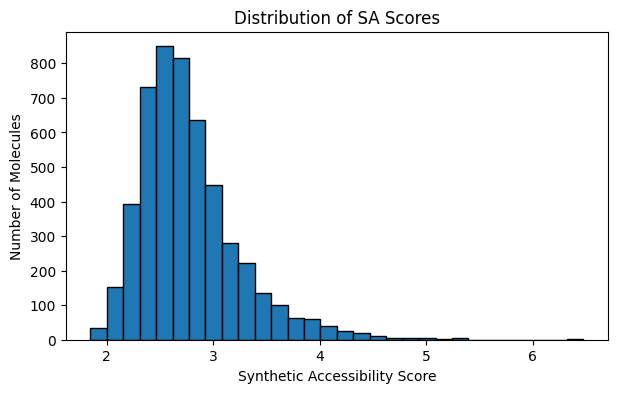

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.hist(
    triazine_df["SA_Score"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Synthetic Accessibility Score")
plt.ylabel("Number of Molecules")
plt.title("Distribution of SA Scores")

plt.show()

In [12]:
triazine_df[
    triazine_df["SA_Score"] > 5
][
    [
        "Triazine_ID",
        "SA_Score",
        "SMILES"
    ]
]

,Triazine_ID,SA_Score,SMILES
171,TRZ00179,5.274676,Cc1nnc(CC23CC4CC(C2)CC(n2ncnn2)(C4)C3)nc1C
844,TRZ00930,5.341760,Cc1nnc(C23CC4CC(C2)CC(n2ncnn2)(C4)C3)nc1C
854,TRZ00940,5.296640,Cc1nnn(C23CC4CC(CC(c5nnc(C)c(C)n5)(C4)C2)C3)n1
1416,TRZ01561,5.230020,Cc1nnc(C23CC4CC(C2)CC(n2cnc(Cl)n2)(C4)C3)nc1C
1445,TRZ01593,6.475175,COc1ccc2c3c1O[C@H]1[C@@]4(OC)C=C[C@@]5(C[C@H]4...
2808,TRZ03082,5.147671,[2H]c1nc([2H])c([2H])c(-c2nnc(C)c(C)n2)c1[2H]
2969,TRZ03260,5.328168,Cc1nnc(-c2ccc3c(c2)C[C@@H]2CC[C@H](C3)[C@]23CN...
3452,TRZ03927,5.328168,Cc1nnc(-c2ccc3c(c2)C[C@H]2CC[C@@H](C3)[C@]23CN...
3627,TRZ04148,5.250086,Cc1nnc(C(C2C3=NCCC3N(N3CC(C)CC(C)C3)c3[nH]ccc3...
4058,TRZ04701,5.050314,CN=NN(C(C)F)[C@@H]1[C@@H](O)[C@H](c2nnc(C)c(C)...


In [14]:
def sa_category(sa):
    if sa < 2:
        return "Very Easy"
    elif sa < 3:
        return "Easy"
    elif sa < 4:
        return "Moderate"
    elif sa < 5:
        return "Difficult"
    else:
        return "Very Difficult"

triazine_df["SA_Category"] = (
    triazine_df["SA_Score"]
    .apply(sa_category)
)

triazine_df["SA_Category"].value_counts()

SA_Category
Easy              3822
Moderate          1063
Difficult          110
Very Easy           34
Very Difficult      10
Name: count, dtype: int64